# Temat projektu: Detekcja emocji w tekście – analiza różnych podejść


## Porównane zostały 3 podejścia:

**1) Model baseline (regresja logistyczna) wykorzystujący reprezentację TF-IDF**

**2) Własny transformer, napisany "od zera"**

**3) Fine-tuning modelu BERT**


## Detekcja emocji w krótkich wpisach internetowych 

- 7 emocji (oryginalnie 13 w datasecie)
- Dataset: zbiór wpisów z Twittera (źródło: https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text/data)
- cały kod znajduje się w repozytorium: https://github.com/MarRac15/Emotion-detection-from-text

## Pytania badawcze (hipotezy):

- Który model poradzi sobie najlepiej?
- Czy złożoność modelu ma rzeczywiście wpływ na skuteczność rozpoznawania emocji w krótkich tekstach? Jak duży?
- Jak najlepiej podejść do problemu rozpoznawania wielu klas emocji?
- Które kategorie emocji są najtrudniejsze do wykrycia? Od czego może to zależeć?

-----------

## Etap 1 - przygotowanie danych

- Dane oryginalnie zawierały 13 klas:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
import random
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

RAW_DATA_PATH = "resources/data/raw/tweet_emotions.csv"

In [2]:
data = pd.read_csv(RAW_DATA_PATH)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   40000 non-null  int64
 1   sentiment  40000 non-null  str  
 2   content    40000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 937.6 KB


In [3]:
pd.unique(data["sentiment"])

<StringArray>
[     'empty',    'sadness', 'enthusiasm',    'neutral',      'worry',
   'surprise',       'love',        'fun',       'hate',  'happiness',
    'boredom',     'relief',      'anger']
Length: 13, dtype: str

In [4]:
print(f"liczba wszystkich wartości NaN w całej tabeli: {data.isna().sum().sum()}")
print(f"liczba wszystkich wartości null w całej tabeli: {data.isnull().sum()}")
print(f"Czy są jakieś duplikaty wpisów: {data.duplicated().sum()}")

liczba wszystkich wartości NaN w całej tabeli: 0
liczba wszystkich wartości null w całej tabeli: tweet_id     0
sentiment    0
content      0
dtype: int64
Czy są jakieś duplikaty wpisów: 0


sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


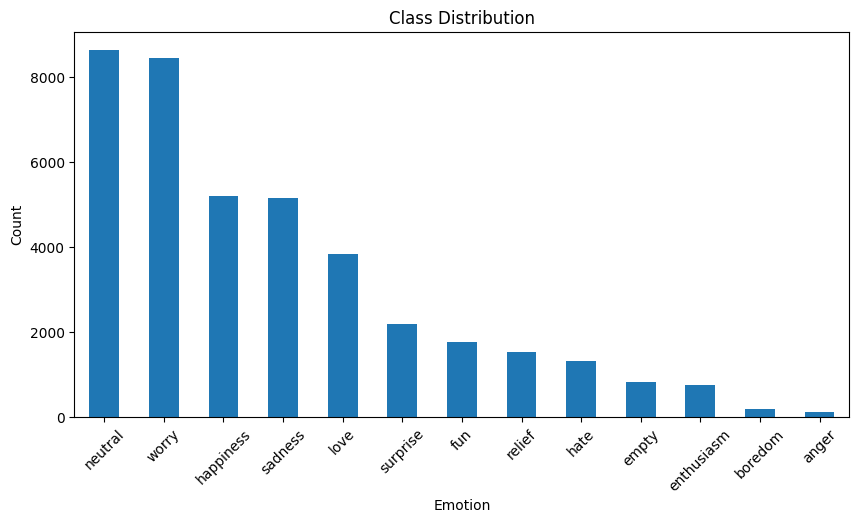

In [5]:
print(data["sentiment"].value_counts())
plt.figure(figsize=(10, 5))
data['sentiment'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Podjęto decyzję o usunięciu klas o bardzo niewielkiej liczbie przykładów.

In [6]:
classes_to_keep = [
    "neutral",
    "worry",
    "happiness",
    "sadness",
    "love",
    "surprise",
    "fun",
    "relief",
    "hate"
]

new_data = data[data["sentiment"].isin(classes_to_keep)].copy()

### Dodatkowo zdecydowano się zmergować klasę fun do happiness oraz worry do sadness - ze względu na podobne znaczenie semantyczne, podobne słownictwo.

In [7]:
def merge_classes(df: pd.DataFrame, merge_map):
    """
    Used for merging certain emotions that overlap with each other (due to simmilar semantic meaning)
    """
    df = df.copy()
    df["sentiment"] = df["sentiment"].replace(merge_map)
    return df

merge_map = {
    "fun": "happiness",
    "worry": "sadness"
}


new_data = merge_classes(new_data, merge_map)
print("Rozkład klas po zmergowaniu:")
print(new_data["sentiment"].value_counts())

Rozkład klas po zmergowaniu:
sentiment
sadness      13624
neutral       8638
happiness     6985
love          3842
surprise      2187
relief        1526
hate          1323
Name: count, dtype: int64


### Zamiana nazwy etykiet na wartości numeryczne:

In [8]:
encoder = LabelEncoder()
new_data["label_id"] = encoder.fit_transform(new_data["sentiment"])
print("Mapowanie klas na id: ")
label_map = dict(enumerate(encoder.classes_))
print(label_map)

Mapowanie klas na id: 
{0: 'happiness', 1: 'hate', 2: 'love', 3: 'neutral', 4: 'relief', 5: 'sadness', 6: 'surprise'}


### Rozkład klas po zbalansowaniu:

In [9]:
print("\nRozkład klas po zbalansowaniu: ")
print(new_data["sentiment"].value_counts().sort_values(ascending=False))
print(round(new_data["sentiment"].value_counts(normalize=True) * 100, 2))


Rozkład klas po zbalansowaniu: 
sentiment
sadness      13624
neutral       8638
happiness     6985
love          3842
surprise      2187
relief        1526
hate          1323
Name: count, dtype: int64
sentiment
sadness      35.74
neutral      22.66
happiness    18.32
love         10.08
surprise      5.74
relief        4.00
hate          3.47
Name: proportion, dtype: float64


### Oczyszczenie tekstów:
- usuwanie linków
- usuwanie wzmianek, np. @Marek
- usuwanie interpunkcji (oprócz apostrfów)
- usuwanie podwójnych spacji

In [11]:
def clean_text(dirty_text: str):
    punctuation = '!?.,;:()[]{}"'
    new_str = dirty_text.lower()
    
    #url
    new_str = re.sub(r"http\S+|www\S+", "", new_str)

    #mentions
    new_str = re.sub(r"@\w+", "", new_str)

    #hashtags
    new_str = re.sub(r"#(\w+)", r"\1", new_str)

    new_str = re.sub(' +', ' ', new_str)

    for char in punctuation:
        new_str = new_str.replace(char, ' ')
    
    new_str = re.sub(r"\s+", " ", new_str)
    
    return new_str.strip()



new_data["clean_text"] = new_data["content"].apply(clean_text)

#czyści puste stringi które powstały po czyszczeniu:
new_data = new_data[new_data["clean_text"].str.strip().astype(bool)]

In [12]:
print(new_data[["content", "clean_text", "sentiment"]].sample(15))
print()
print("BEFORE:", new_data["content"].iloc[0])
print("AFTER :", new_data["clean_text"].iloc[0])

                                                 content  \
13197  @withloverianeee i hav a bet to get a 6 pack i...   
15586  @AmberRainDesign many tribes r becoming extinc...   
38308           Just downloaded a podcast @ the bus stop   
29401  boy don't try to front i-i know just-just what...   
4074   will be attending CIC's parents' orientation t...   
12709          @FTSKirstin im depressed like so baddddd.   
8028        @katebuckjr Sorry I can not reach either URL   
39567                       morning(ish)  hows everyone?   
4975       loves florida but misses her american friends   
17685   @StaceMichelle I doubt I'll get one to be honest   
10198  despertando megadespistado, me ire a la u y lu...   
24548                     @MaheshKukreja You too sweetie   
10647       home, don't feel like going to work tomorrow   
20225  Someone in UNITED STATES liked Jelly Blocks ht...   
27358  Watching 1st Potter film with kids and eating ...   

                                       

### Podział na train, val i test (stratify split):

In [13]:
train_df, temp_df = train_test_split(
    new_data,
    test_size=0.3,
    random_state=42,
    stratify=new_data["sentiment"]
)

#val + test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["sentiment"]
)

### Sprawdzenie czy split wyszedł dobrze:

In [14]:
print(len(train_df), len(val_df), len(test_df))
print(train_df["sentiment"].value_counts(normalize=True))
print(val_df["sentiment"].value_counts(normalize=True))
print(test_df["sentiment"].value_counts(normalize=True))

26635 5707 5708
sentiment
sadness      0.357837
neutral      0.225343
happiness    0.183555
love         0.100957
surprise     0.057443
relief       0.040098
hate         0.034766
Name: proportion, dtype: float64
sentiment
sadness      0.357806
neutral      0.225337
happiness    0.183459
love         0.100929
surprise     0.057473
relief       0.040126
hate         0.034869
Name: proportion, dtype: float64
sentiment
sadness      0.357919
neutral      0.225298
happiness    0.183602
love         0.100911
surprise     0.057463
relief       0.040119
hate         0.034688
Name: proportion, dtype: float64


In [15]:
print(f"liczba wszystkich wartości NaN w całej tabeli: {train_df.isna().sum().sum()}")
print(f"liczba wszystkich wartości null w całej tabeli: {train_df.isnull().sum()}")

print(f"liczba wszystkich wartości NaN w całej tabeli: {val_df.isna().sum().sum()}")
print(f"liczba wszystkich wartości null w całej tabeli: {val_df.isnull().sum()}")

print(f"liczba wszystkich wartości NaN w całej tabeli: {test_df.isna().sum().sum()}")
print(f"liczba wszystkich wartości null w całej tabeli: {test_df.isnull().sum()}")

liczba wszystkich wartości NaN w całej tabeli: 0
liczba wszystkich wartości null w całej tabeli: tweet_id      0
sentiment     0
content       0
label_id      0
clean_text    0
dtype: int64
liczba wszystkich wartości NaN w całej tabeli: 0
liczba wszystkich wartości null w całej tabeli: tweet_id      0
sentiment     0
content       0
label_id      0
clean_text    0
dtype: int64
liczba wszystkich wartości NaN w całej tabeli: 0
liczba wszystkich wartości null w całej tabeli: tweet_id      0
sentiment     0
content       0
label_id      0
clean_text    0
dtype: int64


### Ostatecznie, zapisano zbiory do 3 plików CSV

--------

## Etap 2 - baseline model

1) Wczytano dane z CSV

2) Wykorzystano TF-IDF Vectorizer

3) Przekształcono zbiory X_train, X_val, X_test na wektory TF-IDF

4) Wykorzystano model regresji logistycznej


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Wczytywanie danych:

In [17]:
TRAIN_PATH = "resources/data/train.csv"
TEST_PATH = "resources/data/test.csv"
VAL_PATH = "resources/data/val.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

X_train = train_df["clean_text"]
y_train = train_df["label_id"]

X_val = val_df["clean_text"]
y_val = val_df["label_id"]

X_test = test_df["clean_text"]
y_test = test_df["label_id"]

### TF-IDF:

In [18]:
vectorizer = TfidfVectorizer(analyzer="char", max_features=20000, ngram_range=(3,5))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

### Model regresji logistycznej:

In [19]:
baseline_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced")


baseline_model.fit(X_train_vec, y_train)

y_pred = baseline_model.predict(X_test_vec)

### Ewaluacja i wyniki:

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.37      0.40      1048
           1       0.17      0.43      0.24       198
           2       0.44      0.48      0.46       576
           3       0.44      0.39      0.41      1286
           4       0.11      0.27      0.16       229
           5       0.65      0.43      0.52      2043
           6       0.13      0.24      0.16       328

    accuracy                           0.40      5708
   macro avg       0.34      0.37      0.33      5708
weighted avg       0.47      0.40      0.42      5708



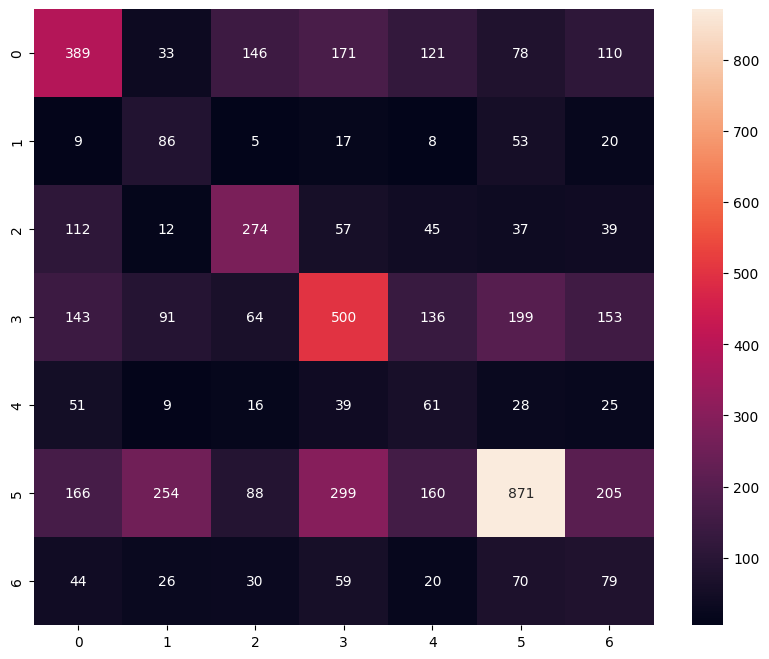

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

{0: 'happiness', 1: 'hate', 2: 'love', 3: 'neutral', 4: 'relief', 5: 'sadness', 6: 'surprise'}

### Analiza błędów:

In [23]:
test_df = test_df.copy()
test_df["pred"] = y_pred
wrong = test_df[test_df["label_id"] != test_df["pred"]]
print(wrong[["clean_text", "label_id", "pred"]].head(20))

                                           clean_text  label_id  pred
0   after a little bit the drink isn't actually so...         3     6
2   just checked the diary and it clashes with usw...         5     1
4   my days been aight been cleaning mostly went t...         5     4
5   lil kim download omq i think i like that sonqq...         5     4
6   sorry we couldn't get the projector working wi...         4     5
7   i got a new high speed machine stuffed with la...         5     1
9   nah to be honest i'm not a 'drinker' as such w...         5     0
11  i'll be back on it later today got plenty of g...         0     4
12  yay buti nagustuhan nyo isang bar lang enclose...         6     3
13                                      holiday again         3     4
15  *sits at the airport waiting for to get here* ...         5     6
16  in the bus almost an hour late because of my c...         5     1
17  in children's hospital er hoping meredith does...         1     5
18                  

## Podsumowanie Etapu 2:

- Accuracy modelu wyniosło ok. 40 %
- Macro F1 modelu: ok. 33 %

#### Najtrudniejsze klasy do wykrycia: surprise i relief
- są najbardziej subtelne
- brakuje śledzenia kontekstu

### Najlepiej wykrywana emocja: sadness
- najwięcej przykładów (imbalance datasetu)

### Pomyłki:
- hate klasyfikowane często jako sadness
- love czasem mylone z happiness


### Wnioski:

- Model regresji stosował jedynie TF-IDF, nie śledzi kontekstu

- Model często myli emocje, które są podobne pod względem semantycznym (podobne słownictwo)

- Różnice w ilości przykładów - niezbalansowany dataset, a regresja sobie z tym nie poradziła

- Model nie posiada umiejętności rozróżniania cech języka

- Model nadal działa lepiej niż gdyby zgadywać


-----------

## Etap 3 - własny transformer

### Wykorzystano ...


### Wyniki ewaluacji:

## Podsumowanie etapu 3 i wnioski:

-----

## Etap 4 - fine-tuning modelu BERT

* Pełny znajduje się w repozytorium, w: src/bert

### Stworzono Dataset (klasę)

### Wykorzystano BertTokenizer od transformers

In [24]:
from sklearn.metrics import accuracy_score, f1_score
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from tqdm import tqdm
from src.bert.dataset import EmotionDataset

g:\University_subjects\deep_learning\emotion_detection_project\Emotion-detection-from-text\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_PATH = "resources/data/train.csv"
TEST_PATH = "resources/data/test.csv"
VAL_PATH = "resources/data/val.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

In [26]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

### Przykład działania tego Tokenizera:

In [27]:
text = train_df["content"].iloc[0]

encoding = tokenizer(
    text,
    truncation=True,
    padding="max_length",
    max_length=32
)

print(tokenizer.convert_ids_to_tokens(encoding["input_ids"]))
print(encoding["attention_mask"])

['[CLS]', '@', 'su', '##zan', '##ella', 'i', 'missed', 'mine', ',', 'too', '.', 'not', 'fun', '.', '.', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Ładowanie danych, za pomocą napisanej klasy EmotionDataset:

In [28]:
train_dataset = EmotionDataset(
    texts=train_df["clean_text"],
    labels=train_df["label_id"],
    tokenizer=tokenizer,
)

val_dataset = EmotionDataset(
    texts=val_df["clean_text"],
    labels=val_df["label_id"],
    tokenizer=tokenizer,
)


#dataloaders:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

### Rozmiar batchy:

In [29]:
batch = next(iter(train_loader))
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)

torch.Size([16, 128])
torch.Size([16, 128])


## Trening:

- 5 epok

- batch_size = 16

- optimizer: AdamW

- learning rate = 2e-5

### Zastosowano early stopping (patience = 2) oraz zapisywanie najlepszego modelu

### W czasie treningu mierzę:
- train loss
- loss na zbiorze walidacyjnym
- accuracy na zbiorze walidacyjnym
- macro F1 na zbiorze walidacyjnym

![Confusion Matrix](resources/training_bert_results.png)

## Ewaluacja na zbiorze testowym:

- przygotowano funkcję do walidacji oraz funkcję dla pojedynczych predykcji

### Ładowanie danych testowych oraz najlepszego zapisanego modelu:

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4328.80it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Class report:
              precision    recall  f1-score   support

           0       0.43      0.58      0.50      1048
           1       0.46      0.26      0.33       198
           2       0.51      0.46      0.48       576
           3       0.51      0.42      0.46      1286
           4       0.23      0.14      0.17       229
           5       0.61      0.71      0.66      2043
           6       0.24      0.09      0.14       328

    accuracy                           0.52      5708
   macro avg       0.43      0.38      0.39      5708
weighted avg       0.50      0.52      0.50      5708




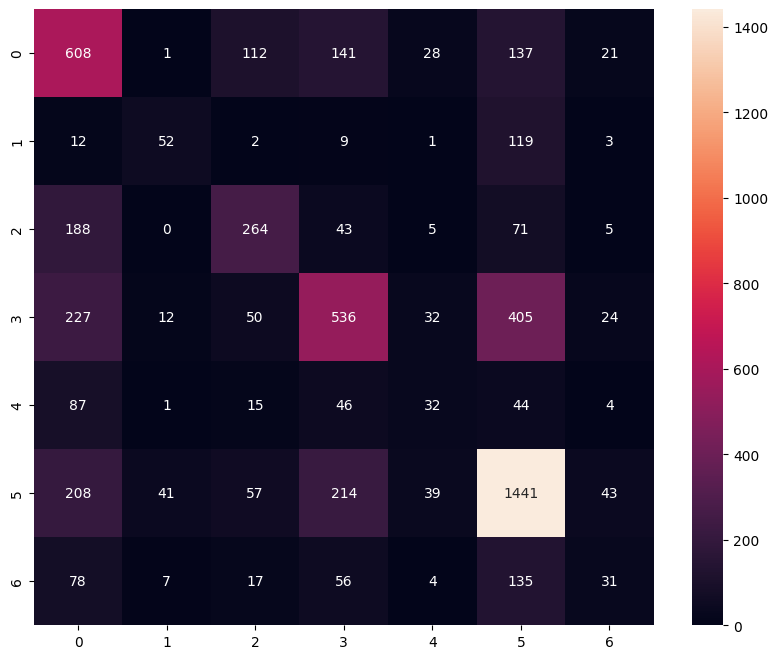

Example prediction: I love this scene when Kenobi shows up
2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6030.39it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [32]:
from src.bert.dataset import EmotionDataset
from src.bert.evaluate import evaluate_test, predict

TRAIN_PATH = "resources/data/train.csv"
TEST_PATH = "resources/data/test.csv"
VAL_PATH = "resources/data/val.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "src/bert/best_bert.pt"


tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

model.load_state_dict(torch.load(MODEL_PATH))
model.to(DEVICE)
model.eval()

test_df = pd.read_csv(TEST_PATH)
test_dataset = EmotionDataset(
    texts=test_df["clean_text"],
    labels=test_df["label_id"],
    tokenizer=tokenizer,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

### Metryki na zbiorze testowym:

In [33]:
all_preds, all_labels = evaluate_test(model, test_loader)
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.43      0.58      0.50      1048
           1       0.46      0.26      0.33       198
           2       0.51      0.46      0.48       576
           3       0.51      0.42      0.46      1286
           4       0.23      0.14      0.17       229
           5       0.61      0.71      0.66      2043
           6       0.24      0.09      0.14       328

    accuracy                           0.52      5708
   macro avg       0.43      0.38      0.39      5708
weighted avg       0.50      0.52      0.50      5708



### Przykładowe predykcje:

In [34]:
test_texts = [
    "I love this scene when Kenobi shows up",
    "I had a rough day",
    "Finally weekend, I am ready"
]

for text in test_texts:
    print(predict(text, model, tokenizer))

2
5
0


{0: 'happiness', 1: 'hate', 2: 'love', 3: 'neutral', 4: 'relief', 5: 'sadness', 6: 'surprise'}

### Analiza błędów:

In [36]:
df_errors = pd.DataFrame({
    "text": test_df["clean_text"].tolist(),
    "true": all_labels,
    "pred": all_preds
})

df_errors["correct"] = df_errors["true"] == df_errors["pred"]

errors = df_errors[df_errors["correct"] == False]
errors.head(15)

,text,true,pred,correct
0,after a little bit the drink isn't actually so...,3,5,False
5,lil kim download omq i think i like that sonqq...,5,0,False
6,sorry we couldn't get the projector working wi...,4,5,False
9,nah to be honest i'm not a 'drinker' as such w...,5,3,False
12,yay buti nagustuhan nyo isang bar lang enclose...,6,3,False
14,kisses or its screwed i'll be a raggy old cat ...,2,5,False
17,in children's hospital er hoping meredith does...,1,5,False
21,it's the final count down to bigger hair people,6,3,False
22,ima cry tht was mean,3,5,False
23,ok bye alex have fun today,3,0,False


## Wnioski z Etapu 4:

### - BERT po 3 epoce przestał się dobrze uczyć - loss na zbiorze walidacyjnym zaczął lekko rosnąć, metryki rosły bardzo niewiele w górę - zastosowany został w końcy early stopping


### - BERT radzi sobie lepiej z kontekstem, daje lepsze wyniki niż regresja logistyczna

### - Na zbiorze testowym: Accuracy 50 % i macro F1 39%

### - Najgorzej wyszły klasy: relief i surprise

### - Słabo sobie radzi z najmniejszymi klasami

### - Model nadal faworyzuje klasy dominujące (sadness, neutral)

### - Model bardzo dobrze wykrywa sadness, love i neutral

### - Skoro nawet BERT nie poradził sobie dobrze z każdą emocją, to potrzebna jest bardziej wyraźna separacja klas lub jeszcze większy rebalansing

### - Niektóre etykiety przypisano w bardzo subiektywny sposób (kolejna wada datasetu)

----------

## WNIOSKI OGÓLNE:

### W metrykach wygrywa model BERT, ale nawet on dość często się myli

### Transformery radzą sobie lepiej niż klasyczne metody uczenia maszynowego i NLP dla tego problemu

### Zbiór danych jest niezbalansowany, na przyszłość trzeba by pomyśleć nad dalszym resamplingiem, a najlepiej znaleźć inny zbiór

### Problem wykrywania tak wielu emocji, z których niektóre się semantycznie pokrywają, jest dosyć złożony - modele nie zawsze odróżniają podobne do siebie emocje

### Najtrudniejsze emocje w tym przypadku to: relief i surprise

### Część problemu może tkwić w subiektywnym sposobie oceny tekstów w zbiorze i pochodzeniu danych (zwłaszcza gdy mamy do czynienia z klasami z niewyraźną separacją)